# Notebook 04 — Two-Tower Baseline

Clean baseline two-tower model for user→business retrieval.

* InfoNCE loss with in-batch negatives (textbook form, no symmetric / no log-q correction).
* Trained on `label==1` interactions only — diagonal-positive assumption holds.
* L2-normalized Qwen category embeddings concatenated with StandardScaled scalar features.
* Two evaluation protocols:
  1. Sampled (1 pos + 99 neg) — same protocol as the SVD baseline in `03_svd_baseline.ipynb`.
  2. Full-catalogue (1 pos vs all train-set businesses).
* Final user / business embedding tables + scalers + checkpoint exported under
  `qdrant_export/` for downstream Qdrant ingestion.

Inputs come from `02_preprocessing.ipynb` — read from `/content/drive/My Drive/rec_system/new/`.

## Setup

In [1]:
!pip install -q --upgrade "torch>=2.4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 143.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 605.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import os
import json
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}  |  mem: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA A100-SXM4-80GB  |  mem: 85.1 GB


## Load Data

In [4]:
DATA_DIR    = "/content/drive/My Drive/rec_system/newV2"
RESULTS_DIR = f"{DATA_DIR}/04_output_results"
EXPORT_DIR  = f"{DATA_DIR}/qdrant_export"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(EXPORT_DIR,  exist_ok=True)

train_reviews = pd.read_parquet(f"{DATA_DIR}/train_reviews.parquet")
val_reviews   = pd.read_parquet(f"{DATA_DIR}/val_reviews.parquet")
test_reviews  = pd.read_parquet(f"{DATA_DIR}/test_reviews.parquet")

users_df      = pd.read_parquet(f"{DATA_DIR}/users.parquet")
businesses_df = pd.read_parquet(f"{DATA_DIR}/businesses.parquet")

user_cat_emb     = np.load(f"{DATA_DIR}/user_category_embeddings.npy")
business_cat_emb = np.load(f"{DATA_DIR}/business_category_embeddings.npy")

user_emb_index     = pd.read_parquet(f"{DATA_DIR}/user_embedding_index.parquet")
business_emb_index = pd.read_parquet(f"{DATA_DIR}/business_embedding_index.parquet")

user_to_emb_idx     = {uid: i for i, uid in enumerate(user_emb_index["user_id"])}
business_to_emb_idx = {bid: i for i, bid in enumerate(business_emb_index["business_id"])}

print(f"Train: {len(train_reviews):,}  |  Val: {len(val_reviews):,}  |  Test: {len(test_reviews):,}")
print(f"Users: {len(users_df):,}  |  Businesses: {len(businesses_df):,}")
print(f"Qwen user emb: {user_cat_emb.shape}  |  business emb: {business_cat_emb.shape}")

Train: 1,990,604  |  Val: 166,488  |  Test: 166,488
Users: 162,366  |  Businesses: 44,582
Qwen user emb: (162366, 1024)  |  business emb: (44582, 1024)


## Feature Columns

In [5]:
USER_SCALAR_COLS = [
    "avg_stars_given",
    "review_count_log",
    "yelping_since_years",
    "is_elite",
    "avg_useful_per_review",
    "social_activity_log",
    "user_price_preference",
]

# city_encoded / state_encoded omitted: LabelEncoder integers are nominal,
# StandardScaler treats them as continuous — adds noise, not signal.
# Geographic context already lives in the Qwen category embedding.
BUSINESS_SCALAR_COLS = [
    "avg_stars", "review_count_log", "price_range",
    "noise_level", "alcohol", "outdoor_seating", "takes_reservations",
    "restaurants_take_out", "restaurants_delivery",
    "good_for_kids", "good_for_groups", "attire",
    "ambience_romantic", "ambience_intimate", "ambience_classy",
    "ambience_hipster", "ambience_divey", "ambience_touristy",
    "ambience_trendy", "ambience_upscale", "ambience_casual",
    "good_for_meal_breakfast", "good_for_meal_brunch", "good_for_meal_lunch",
    "good_for_meal_dinner", "good_for_meal_latenight", "good_for_meal_dessert",
]

print(f"User scalar features:     {len(USER_SCALAR_COLS)}")
print(f"Business scalar features: {len(BUSINESS_SCALAR_COLS)}")

User scalar features:     7
Business scalar features: 27


## Preprocessing

In [6]:
from sklearn.preprocessing import StandardScaler

# Median imputation on businesses. Capture the medians — deployment must use
# the same values when imputing new businesses at inference time.
business_medians = {}
for col in BUSINESS_SCALAR_COLS:
    if businesses_df[col].isnull().any():
        m = float(businesses_df[col].median())
        business_medians[col] = m
        businesses_df[col] = businesses_df[col].fillna(m)

# Scalers fit on TRAIN-set users / businesses only (no val / test leakage).
train_users_set      = set(train_reviews["user_id"].unique())
train_businesses_set = set(train_reviews["business_id"].unique())

user_scaler = StandardScaler().fit(
    users_df[users_df["user_id"].isin(train_users_set)][USER_SCALAR_COLS]
)
business_scaler = StandardScaler().fit(
    businesses_df[businesses_df["business_id"].isin(train_businesses_set)][BUSINESS_SCALAR_COLS]
)

users_df[USER_SCALAR_COLS]          = user_scaler.transform(users_df[USER_SCALAR_COLS])
businesses_df[BUSINESS_SCALAR_COLS] = business_scaler.transform(businesses_df[BUSINESS_SCALAR_COLS])

# L2-normalize Qwen embeddings: raw per-dim magnitude is ~0.03 vs std-1
# scalars; without this the first linear layer is dominated by scalars
# and Qwen contributes nothing meaningful.
user_cat_emb     = (user_cat_emb     / (np.linalg.norm(user_cat_emb,     axis=1, keepdims=True) + 1e-8)).astype(np.float32)
business_cat_emb = (business_cat_emb / (np.linalg.norm(business_cat_emb, axis=1, keepdims=True) + 1e-8)).astype(np.float32)

print(f"Scalars normalized | Qwen L2-normed | imputed medians for {len(business_medians)} columns")

Scalars normalized | Qwen L2-normed | imputed medians for 25 columns


## Aligned Feature Matrices

In [7]:
# Build a single (N, D) feature matrix per side, with stable row order.
# Training and eval pass integer indices; feature lookups are tensor index
# ops on a GPU-resident matrix — no per-row stack() / per-batch concat.
user_ids_ordered     = users_df["user_id"].tolist()
business_ids_ordered = businesses_df["business_id"].tolist()

user_id_to_idx     = {uid: i for i, uid in enumerate(user_ids_ordered)}
business_id_to_idx = {bid: i for i, bid in enumerate(business_ids_ordered)}

user_qwen_aligned     = np.stack([user_cat_emb    [user_to_emb_idx[u]]     for u in user_ids_ordered]).astype(np.float32)
business_qwen_aligned = np.stack([business_cat_emb[business_to_emb_idx[b]] for b in business_ids_ordered]).astype(np.float32)

user_feats_np = np.concatenate(
    [users_df[USER_SCALAR_COLS].values.astype(np.float32), user_qwen_aligned],
    axis=1,
)
item_feats_np = np.concatenate(
    [businesses_df[BUSINESS_SCALAR_COLS].values.astype(np.float32), business_qwen_aligned],
    axis=1,
)

user_feats = torch.tensor(user_feats_np, dtype=torch.float32, device=device)
item_feats = torch.tensor(item_feats_np, dtype=torch.float32, device=device)

USER_INPUT_DIM = user_feats.shape[1]
ITEM_INPUT_DIM = item_feats.shape[1]
print(f"user_feats: {tuple(user_feats.shape)}  |  item_feats: {tuple(item_feats.shape)}")

user_feats: (162366, 1031)  |  item_feats: (44582, 1051)


## Model

In [8]:
class Tower(nn.Module):
    def __init__(self, input_dim, embedding_dim=128, hidden_dims=(512, 256), dropout=0.2):
        super().__init__()
        self.input_norm = nn.LayerNorm(input_dim)
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        self.hidden = nn.Sequential(*layers)
        self.output = nn.Linear(prev, embedding_dim)

    def forward(self, x):
        return self.output(self.hidden(self.input_norm(x)))


class TwoTowerModel(nn.Module):
    def __init__(self, user_input_dim, item_input_dim,
                 embedding_dim=128, hidden_dims=(512, 256), dropout=0.2):
        super().__init__()
        self.user_tower = Tower(user_input_dim, embedding_dim, hidden_dims, dropout)
        self.item_tower = Tower(item_input_dim, embedding_dim, hidden_dims, dropout)
        self.embedding_dim = embedding_dim

    def forward(self, user_feats, item_feats):
        return (F.normalize(self.user_tower(user_feats), dim=1),
                F.normalize(self.item_tower(item_feats), dim=1))

    def encode_user(self, x): return F.normalize(self.user_tower(x), dim=1)
    def encode_item(self, x): return F.normalize(self.item_tower(x), dim=1)

## Dataset and Loss

In [9]:
class PairDataset(Dataset):
    """Yields (user_idx, item_idx) for label==1 rows only.

    InfoNCE treats every diagonal pair as a positive, so label==0 rows
    must not enter the dataset.
    """
    def __init__(self, reviews_df, user_id_to_idx, business_id_to_idx):
        df = reviews_df[reviews_df["label"] == 1]
        df = df[df["user_id"].isin(user_id_to_idx) & df["business_id"].isin(business_id_to_idx)]
        self.user_idx = torch.tensor([user_id_to_idx[u]     for u in df["user_id"]],     dtype=torch.long)
        self.item_idx = torch.tensor([business_id_to_idx[b] for b in df["business_id"]], dtype=torch.long)

    def __len__(self): return len(self.user_idx)
    def __getitem__(self, i): return self.user_idx[i], self.item_idx[i]


class InfoNCELoss(nn.Module):
    """Textbook InfoNCE with in-batch negatives.

    Future extension to revisit once the baseline metrics stabilize:
    sampling-bias correction (Yi et al. 2019) — subtract log P(item_j) from
    each column of the score matrix to debias popular items appearing as
    in-batch negatives. Skipped here for simplicity.
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, user_emb, item_emb):
        scores  = (user_emb @ item_emb.T) / self.temperature
        targets = torch.arange(user_emb.size(0), device=user_emb.device)
        return F.cross_entropy(scores, targets)

## Training

In [10]:
BATCH_SIZE    = 4096
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-5
NUM_EPOCHS    = 75
PATIENCE      = 5
TEMPERATURE   = 0.07

train_ds = PairDataset(train_reviews, user_id_to_idx, business_id_to_idx)
val_ds   = PairDataset(val_reviews,   user_id_to_idx, business_id_to_idx)
print(f"Train pairs: {len(train_ds):,}  |  Val pairs: {len(val_ds):,}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

model = TwoTowerModel(USER_INPUT_DIM, ITEM_INPUT_DIM,
                      embedding_dim=128, hidden_dims=(512, 256), dropout=0.2).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
criterion = InfoNCELoss(temperature=TEMPERATURE)
scaler = torch.cuda.amp.GradScaler()

n_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {n_params:,}  (user_dim={USER_INPUT_DIM}, item_dim={ITEM_INPUT_DIM})")
print(f"Train batches/epoch: {len(train_loader):,}  |  Val batches/epoch: {len(val_loader):,}")

Train pairs: 1,411,589  |  Val pairs: 116,404
Model params: 1,402,692  (user_dim=1031, item_dim=1051)
Train batches/epoch: 344  |  Val batches/epoch: 28


/tmp/ipykernel_1204/2079177666.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [11]:
def train_epoch(model, loader, optimizer, criterion, scaler, user_feats, item_feats, device):
    model.train()
    total, n = 0.0, 0
    pbar = tqdm(loader, desc="train", leave=False)
    for u_idx, i_idx in pbar:
        u_idx, i_idx = u_idx.to(device), i_idx.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            ue, ie = model(user_feats[u_idx], item_feats[i_idx])
            loss = criterion(ue, ie)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total += loss.item(); n += 1
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
    return total / max(n, 1)


def validate(model, loader, criterion, user_feats, item_feats, device):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for u_idx, i_idx in tqdm(loader, desc="val", leave=False):
            u_idx, i_idx = u_idx.to(device), i_idx.to(device)
            with torch.cuda.amp.autocast():
                ue, ie = model(user_feats[u_idx], item_feats[i_idx])
                loss = criterion(ue, ie)
            total += loss.item(); n += 1
    return total / max(n, 1)

In [12]:
ckpt_path = f"{DATA_DIR}/two_tower_best.pt"

train_losses, val_losses = [], []
best_val, no_improve = float("inf"), 0

for epoch in range(NUM_EPOCHS):
    t = train_epoch(model, train_loader, optimizer, criterion, scaler, user_feats, item_feats, device)
    v = validate  (model, val_loader,   criterion,                  user_feats, item_feats, device)
    train_losses.append(t); val_losses.append(v)
    scheduler.step(v)

    new_best = v < best_val
    marker = "  <-- new best" if new_best else f"  (no improve {no_improve + 1}/{PATIENCE})"
    print(f"epoch {epoch + 1:2d}/{NUM_EPOCHS}  train={t:.4f}  val={v:.4f}  lr={optimizer.param_groups[0]['lr']:.2e}{marker}")

    if new_best:
        best_val, no_improve = v, 0
        torch.save(model.state_dict(), ckpt_path)
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stop at epoch {epoch + 1}")
            break

print(f"\nBest val loss: {best_val:.4f}  |  checkpoint: {ckpt_path}")

train:   0%|          | 0/344 [00:00<?, ?it/s]

/tmp/ipykernel_1204/1861015525.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


val:   0%|          | 0/28 [00:00<?, ?it/s]

/tmp/ipykernel_1204/1861015525.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


epoch  1/75  train=7.6503  val=9.5689  lr=1.00e-03  <-- new best


...

val:   0%|          | 0/28 [00:00<?, ?it/s]

epoch 74/75  train=5.0537  val=8.0547  lr=5.00e-04  <-- new best


train:   0%|          | 0/344 [00:00<?, ?it/s]

val:   0%|          | 0/28 [00:00<?, ?it/s]

epoch 75/75  train=5.0500  val=8.0507  lr=5.00e-04  <-- new best

Best val loss: 8.0507  |  checkpoint: /content/drive/My Drive/rec_system/newV2/two_tower_best.pt


## Loss Curves

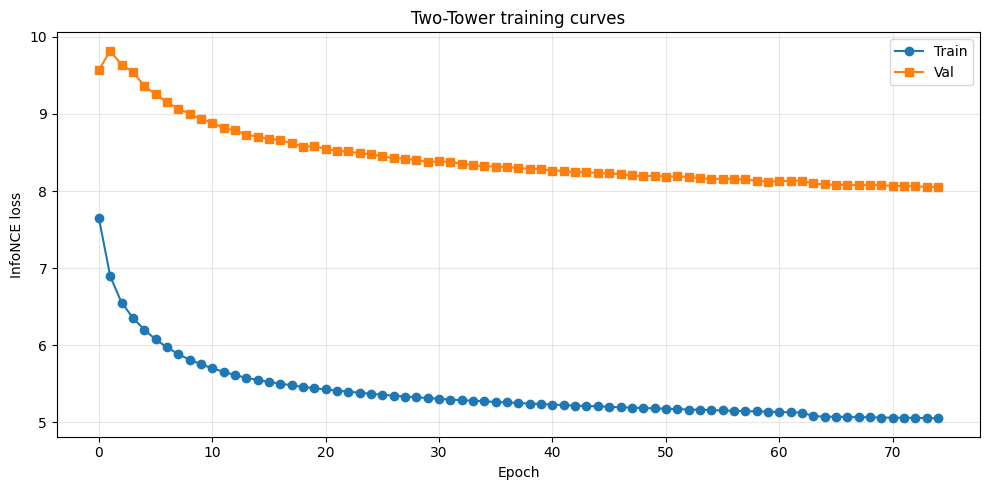

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, marker="o", label="Train")
plt.plot(val_losses,   marker="s", label="Val")
plt.xlabel("Epoch"); plt.ylabel("InfoNCE loss")
plt.title("Two-Tower training curves")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

## Evaluation

In [14]:
# Reload best checkpoint before scoring.
model.load_state_dict(torch.load(ckpt_path))
model.eval()
print("Loaded best checkpoint")

Loaded best checkpoint


In [15]:
def evaluate_sampled(model, eval_df, train_df, user_feats, item_feats, device,
                     n_negatives=99, ks=(5, 10, 20), seed=SEED, split_name="eval"):
    """1 pos + 99 random negatives, train-seen items excluded.

    Same protocol as `03_svd_baseline.ipynb` so two-tower vs SVD numbers are
    apples-to-apples.
    """
    rng = np.random.default_rng(seed)
    # Match SVD baseline pool exactly: sample only from train businesses.
    train_biz_set = set(train_df["business_id"].unique())
    all_bids = np.array([b for b in business_id_to_idx.keys() if b in train_biz_set])
    user_seen = train_df.groupby("user_id")["business_id"].apply(set).to_dict()

    pos = eval_df[(eval_df["label"] == 1)
                  & eval_df["user_id"].isin(user_id_to_idx)
                  & eval_df["business_id"].isin(business_id_to_idx)]

    ranks = []
    model.eval()
    with torch.no_grad():
        for uid, pos_bid in tqdm(zip(pos["user_id"].values, pos["business_id"].values),
                                 total=len(pos), desc=f"sampled [{split_name}]", leave=False):
            seen = user_seen.get(uid, set())
            pool = rng.choice(all_bids, n_negatives * 3, replace=False)
            negs = [b for b in pool if b not in seen and b != pos_bid][:n_negatives]
            if len(negs) < n_negatives:
                continue
            cand = torch.tensor(
                [business_id_to_idx[pos_bid]] + [business_id_to_idx[b] for b in negs],
                dtype=torch.long, device=device,
            )
            u = torch.tensor([user_id_to_idx[uid]], dtype=torch.long, device=device)
            ue = model.encode_user(user_feats[u])
            ie = model.encode_item(item_feats[cand])
            scores = (ue @ ie.T).squeeze(0).cpu().numpy()
            ranks.append(int((scores > scores[0]).sum()) + 1)
    ranks = np.array(ranks)

    rows = []
    for k in ks:
        hits = (ranks <= k).astype(float)
        rows.append({
            "K":           k,
            "NDCG@K":      float(np.where(ranks <= k, 1.0 / np.log2(ranks + 1), 0.0).mean()),
            "Precision@K": float((hits / k).mean()),
            "Recall@K":    float(hits.mean()),
            "Hit@K":       float(hits.mean()),
        })
    df = pd.DataFrame(rows).set_index("K")
    print(f"\n{split_name} sampled (1 pos + {n_negatives} neg):")
    print(df.round(4).to_string())
    return df

In [16]:
def evaluate_ranking(model, eval_df, train_df, user_feats, item_feats, device,
                     ks=(5, 10, 20), split_name="eval"):
    """Full-catalogue ranking: 1 positive vs all train-set businesses.

    Restricting candidates to train-set items matches the SVD baseline pool
    (SVD has no factors for items it didn't see at fit time).
    """
    train_biz_set = set(train_df["business_id"].unique())
    cand_idx = torch.tensor(
        [business_id_to_idx[b] for b in business_ids_ordered if b in train_biz_set],
        dtype=torch.long, device=device,
    )
    bidx_to_pos = {int(idx): pos for pos, idx in enumerate(cand_idx.tolist())}

    model.eval()
    with torch.no_grad():
        item_emb_chunks = []
        for s in range(0, len(cand_idx), 2048):
            item_emb_chunks.append(model.encode_item(item_feats[cand_idx[s:s + 2048]]).cpu())
        item_embs = torch.cat(item_emb_chunks, dim=0)

    seen_by_uidx = {}
    for uid, group in train_df.groupby("user_id"):
        if uid not in user_id_to_idx:
            continue
        seen_by_uidx[user_id_to_idx[uid]] = [
            bidx_to_pos[business_id_to_idx[b]]
            for b in group["business_id"]
            if b in business_id_to_idx and business_id_to_idx[b] in bidx_to_pos
        ]

    pos = eval_df[(eval_df["label"] == 1)
                  & eval_df["user_id"].isin(user_id_to_idx)
                  & eval_df["business_id"].isin(business_id_to_idx)
                  & eval_df["business_id"].isin(train_biz_set)].reset_index(drop=True)

    ranks = []
    bsz = 512
    with torch.no_grad():
        for start in tqdm(range(0, len(pos), bsz), desc=f"full-cat [{split_name}]", leave=False):
            rows = pos.iloc[start:start + bsz]
            u_idx = torch.tensor([user_id_to_idx[u] for u in rows["user_id"]],
                                 dtype=torch.long, device=device)
            ue = model.encode_user(user_feats[u_idx]).cpu()
            scores = (ue @ item_embs.T).numpy()
            for i, (_, row) in enumerate(rows.iterrows()):
                target_pos = bidx_to_pos[business_id_to_idx[row["business_id"]]]
                seen = [s for s in seen_by_uidx.get(user_id_to_idx[row["user_id"]], []) if s != target_pos]
                if seen:
                    scores[i, seen] = -np.inf
                ranks.append(int((scores[i] > scores[i, target_pos]).sum()) + 1)
    ranks = np.array(ranks)

    rows_out = []
    for k in ks:
        hits = (ranks <= k).astype(float)
        rows_out.append({
            "K":           k,
            "NDCG@K":      float(np.where(ranks <= k, 1.0 / np.log2(ranks + 1), 0.0).mean()),
            "Precision@K": float((hits / k).mean()),
            "Recall@K":    float(hits.mean()),
            "Hit@K":       float(hits.mean()),
        })
    df = pd.DataFrame(rows_out).set_index("K")
    print(f"\n{split_name} full-catalogue ({len(cand_idx):,} items):")
    print(df.round(4).to_string())
    return df

In [17]:
val_sampled  = evaluate_sampled(model, val_reviews,  train_reviews, user_feats, item_feats, device, split_name="Val")
test_sampled = evaluate_sampled(model, test_reviews, train_reviews, user_feats, item_feats, device, split_name="Test")
val_full     = evaluate_ranking(model, val_reviews,  train_reviews, user_feats, item_feats, device, split_name="Val")
test_full    = evaluate_ranking(model, test_reviews, train_reviews, user_feats, item_feats, device, split_name="Test")

val_sampled .to_csv(f"{RESULTS_DIR}/two_tower_val_sampled.csv")
test_sampled.to_csv(f"{RESULTS_DIR}/two_tower_test_sampled.csv")
val_full    .to_csv(f"{RESULTS_DIR}/two_tower_val_fullcat.csv")
test_full   .to_csv(f"{RESULTS_DIR}/two_tower_test_fullcat.csv")

pd.DataFrame({
    "epoch":      range(1, len(train_losses) + 1),
    "train_loss": train_losses,
    "val_loss":   val_losses,
}).to_csv(f"{RESULTS_DIR}/two_tower_training_history.csv", index=False)

print(f"\nSaved metrics + training history to {RESULTS_DIR}")

sampled [Val]:   0%|          | 0/116404 [00:00<?, ?it/s]


Val sampled (1 pos + 99 neg):
    NDCG@K  Precision@K  Recall@K   Hit@K
K                                        
5   0.3329       0.0910    0.4552  0.4552
10  0.3731       0.0580    0.5796  0.5796
20  0.4058       0.0355    0.7091  0.7091


sampled [Test]:   0%|          | 0/115373 [00:00<?, ?it/s]


Test sampled (1 pos + 99 neg):
    NDCG@K  Precision@K  Recall@K   Hit@K
K                                        
5   0.3109       0.0856    0.4279  0.4279
10  0.3503       0.0550    0.5499  0.5499
20  0.3834       0.0340    0.6810  0.6810


full-cat [Val]:   0%|          | 0/228 [00:00<?, ?it/s]


Val full-catalogue (39,111 items):
    NDCG@K  Precision@K  Recall@K   Hit@K
K                                        
5   0.0195       0.0050    0.0250  0.0250
10  0.0221       0.0033    0.0333  0.0333
20  0.0252       0.0023    0.0453  0.0453


full-cat [Test]:   0%|          | 0/226 [00:00<?, ?it/s]


Test full-catalogue (39,111 items):
    NDCG@K  Precision@K  Recall@K   Hit@K
K                                        
5   0.0173       0.0044    0.0220  0.0220
10  0.0196       0.0029    0.0293  0.0293
20  0.0225       0.0020    0.0407  0.0407

Saved metrics + training history to /content/drive/My Drive/rec_system/newV2/04_output_results


## Comparison vs. SVD Baseline

In [21]:
READ_DIR    = "/content/drive/My Drive/rec_system/newV2/resultsV2"
try:
    svd_val_s  = pd.read_csv(f"{READ_DIR}/svd_val_metrics_k100.csv",  index_col="K")
    svd_test_s = pd.read_csv(f"{READ_DIR}/svd_test_metrics_k100.csv", index_col="K")
    print("Sampled (1 pos + 99 neg) — NDCG@K\n")
    cmp_val = pd.DataFrame({
        "SVD":      svd_val_s ["NDCG@K"],
        "TwoTower": val_sampled["NDCG@K"],
        "delta_%":  ((val_sampled["NDCG@K"] - svd_val_s ["NDCG@K"]) / svd_val_s ["NDCG@K"] * 100).round(2),
    })
    cmp_test = pd.DataFrame({
        "SVD":      svd_test_s["NDCG@K"],
        "TwoTower": test_sampled["NDCG@K"],
        "delta_%":  ((test_sampled["NDCG@K"] - svd_test_s["NDCG@K"]) / svd_test_s["NDCG@K"] * 100).round(2),
    })
    print("Validation:"); print(cmp_val.round(4)); print()
    print("Test:");       print(cmp_test.round(4))
except FileNotFoundError:
    print("SVD baseline metrics not found in results/. Run notebook 03 first to enable comparison.")

Sampled (1 pos + 99 neg) — NDCG@K

Validation:
       SVD  TwoTower  delta_%
K                            
5   0.0789    0.3329   322.11
10  0.1101    0.3731   239.02
20  0.1501    0.4058   170.33

Test:
       SVD  TwoTower  delta_%
K                            
5   0.0805    0.3109   286.20
10  0.1123    0.3503   211.88
20  0.1528    0.3834   150.95


## Save Embeddings + Artifacts for Qdrant Deployment

Writes everything the deployment side needs to (a) push the trained item
catalog into Qdrant and (b) re-encode any new user / business at query time:

* `user_embeddings.npy`, `business_embeddings.npy` — trained 128-d vectors,
  row-aligned with their respective index parquet (row `i` ↔ `user_id` /
  `business_id` at row `i` of the index parquet).
* `user_embedding_index.parquet`, `business_embedding_index.parquet` — id
  alignment.
* `user_scaler.joblib`, `business_scaler.joblib` — fitted StandardScalers
  for transforming new scalar features at inference time.
* `business_medians.json` — median values used for NA imputation, needed
  when a new business has missing attributes at deployment.
* `two_tower_best.pt` — model `state_dict` (re-encode any new user / item).
* `model_meta.json` — input dims, embedding dim, hidden dims, dropout,
  scalar column ordering, temperature, seed. Enough metadata to rebuild
  the towers without rerunning this notebook.

In [19]:
import joblib

model.eval()
with torch.no_grad():
    u_chunks = []
    for s in range(0, len(user_feats), 4096):
        u_chunks.append(model.encode_user(user_feats[s:s + 4096]).cpu().numpy())
    user_embs = np.concatenate(u_chunks, axis=0)

    i_chunks = []
    for s in range(0, len(item_feats), 4096):
        i_chunks.append(model.encode_item(item_feats[s:s + 4096]).cpu().numpy())
    item_embs = np.concatenate(i_chunks, axis=0)

assert user_embs.shape == (len(user_ids_ordered),     model.embedding_dim)
assert item_embs.shape == (len(business_ids_ordered), model.embedding_dim)

np.save(f"{EXPORT_DIR}/user_embeddings.npy",     user_embs)
np.save(f"{EXPORT_DIR}/business_embeddings.npy", item_embs)

pd.DataFrame({"user_id":     user_ids_ordered    }).to_parquet(
    f"{EXPORT_DIR}/user_embedding_index.parquet",     index=False)
pd.DataFrame({"business_id": business_ids_ordered}).to_parquet(
    f"{EXPORT_DIR}/business_embedding_index.parquet", index=False)

joblib.dump(user_scaler,     f"{EXPORT_DIR}/user_scaler.joblib")
joblib.dump(business_scaler, f"{EXPORT_DIR}/business_scaler.joblib")
with open(f"{EXPORT_DIR}/business_medians.json", "w") as f:
    json.dump(business_medians, f, indent=2)

torch.save(model.state_dict(), f"{EXPORT_DIR}/two_tower_best.pt")

meta = {
    "embedding_dim":        int(model.embedding_dim),
    "user_input_dim":       int(USER_INPUT_DIM),
    "item_input_dim":       int(ITEM_INPUT_DIM),
    "hidden_dims":          [512, 256],
    "dropout":              0.2,
    "user_scalar_cols":     USER_SCALAR_COLS,
    "business_scalar_cols": BUSINESS_SCALAR_COLS,
    "qwen_dim":             1024,
    "qwen_l2_normalize":    True,
    "temperature":          TEMPERATURE,
    "seed":                 SEED,
    "best_val_loss":        float(best_val),
    "n_users":              len(user_ids_ordered),
    "n_businesses":         len(business_ids_ordered),
}
with open(f"{EXPORT_DIR}/model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"Wrote {EXPORT_DIR}/:")
for fn in sorted(os.listdir(EXPORT_DIR)):
    size_mb = os.path.getsize(f"{EXPORT_DIR}/{fn}") / 1e6
    print(f"  {fn:<42s} {size_mb:7.2f} MB")

Wrote /content/drive/My Drive/rec_system/newV2/qdrant_export/:
  business_embedding_index.parquet              1.14 MB
  business_embeddings.npy                      22.83 MB
  business_medians.json                         0.00 MB
  business_scaler.joblib                        0.00 MB
  model_meta.json                               0.00 MB
  two_tower_best.pt                             5.62 MB
  user_embedding_index.parquet                  3.94 MB
  user_embeddings.npy                          83.13 MB
  user_scaler.joblib                            0.00 MB
